# Lab 05 Data visualization with matplotlib and seaborn

Nice visualization libraries:
- matplotlib: https://matplotlib.org/stable/index.html
- seaborn: http://seaborn.pydata.org/
- bokeh: https://docs.bokeh.org/en/latest/
- folium (geospatial visualization): https://python-visualization.github.io/folium/latest/
- kepler.gl (large-scale geospatial visualization): https://kepler.gl/

## Please submit your finished lab05 jupyter notebook via pull request in GitHub

In [1]:
# magic command to display matplotlib plots inline within the ipython notebook webpage
%matplotlib inline

# import necessary modules
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import matplotlib.cm as cm, matplotlib.font_manager as fm
import seaborn as sns

## load the data sets

In [2]:
# load the gps coordinate data, using the date as the full set's index
# the data files are encoded as utf-8: specify so to prevent matplotlib from choking on diacritics
df = pd.read_csv('data/summer-travel-gps-full.csv', encoding='utf-8', index_col='date', parse_dates=True)
rs = pd.read_csv('data/summer-travel-gps-dbscan.csv', encoding='utf-8')

In [3]:
df.head()

,lat,lon,city,country
date,,,,
2014-05-14 09:07:00,51.481292,-0.451011,West Drayton,United Kingdom
2014-05-14 09:22:00,51.474005,-0.450999,Hounslow,United Kingdom
2014-05-14 10:51:00,51.478199,-0.446081,Hounslow,United Kingdom
2014-05-14 11:24:00,51.478199,-0.446081,Hounslow,United Kingdom
2014-05-14 11:38:00,51.474146,-0.451562,Hounslow,United Kingdom


In [4]:
rs.head()

,lat,lon,date,city,country
0,51.478199,-0.446081,05/14/2014 10:51,Hounslow,United Kingdom
1,38.781775,-9.137544,05/14/2014 15:11,Lisbon,Portugal
2,38.771939,-9.128911,05/14/2014 15:41,Lisbon,Portugal
3,38.742987,-9.147780,05/14/2014 16:11,Lisbon,Portugal
4,38.693780,-9.206363,05/15/2014 14:19,Lisbon,Portugal


## First up: Bar Charts

C:\Users\epicm\AppData\Local\Temp\ipykernel_10408\2637334504.py:8: UserWarning: 
The palette list has fewer values (9) than needed (15) and will cycle, which may produce an uninterpretable plot.
  visited_countries = sns.barplot(x="country", y= "count", data=country_counts, hue = "country", palette=sns.hls_palette(9, l=.5, s=.5), edgecolor='k', legend = False)


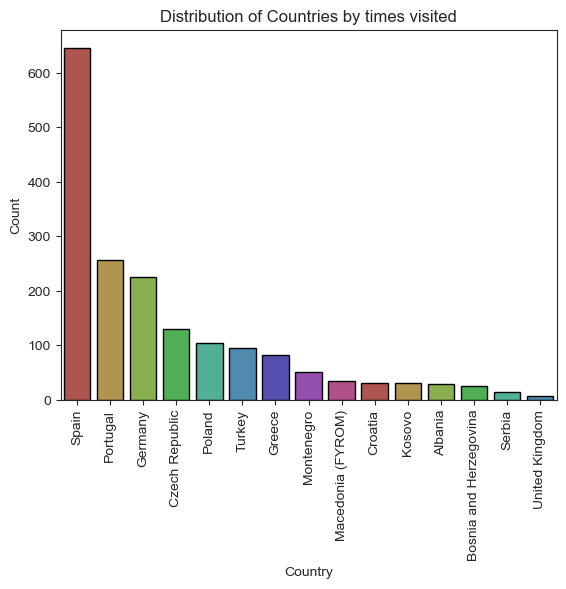

In [20]:
# Q1: Can you draw a bar chart for the most visited countries by using matplotlib and seaborn? You can use the df dataframe.
# Please style the chart to make it look nicer
# such as figsize, width, alpha, color, edgecolor, grid, xlim, and ylim
country_counts = df["country"].value_counts().reset_index()
country_counts.columns = ["country", "count"]

sns.set_style("ticks")
visited_countries = sns.barplot(x="country", y= "count", data=country_counts, hue = "country", palette=sns.hls_palette(9, l=.5, s=.5), edgecolor='k', legend = False)
visited_countries.set_title("Distribution of Countries by times visited")
visited_countries.set_ylabel('Count')
visited_countries.set_xlabel('Country')
for item in visited_countries.get_xticklabels():
    item.set_rotation(90)

Now you try: re-create the plot above, but make the bars orange with maroon edges.

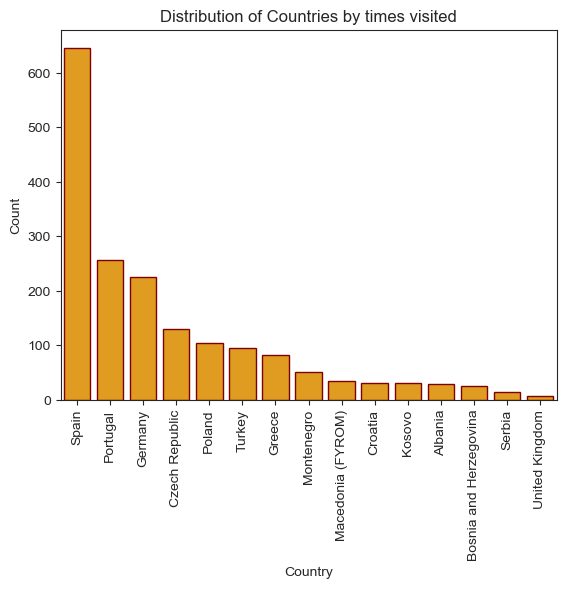

In [ ]:
country_counts = df["country"].value_counts().reset_index()
country_counts.columns = ["country", "count"]

sns.set_style("ticks")
visited_countries = sns.barplot(x="country", y= "count", data=country_counts, edgecolor='maroon', color = "orange", legend = False)
visited_countries.set_title("Distribution of Countries by times visited")
visited_countries.set_ylabel('Count')
visited_countries.set_xlabel('Country')
for item in visited_countries.get_xticklabels():
    item.set_rotation(90)

C:\Users\epicm\AppData\Local\Temp\ipykernel_10408\1113214300.py:7: UserWarning: 
The palette list has fewer values (9) than needed (10) and will cycle, which may produce an uninterpretable plot.
  visited_countries = sns.barplot(x="city", y= "count", data=city_counts, hue = "city", palette=sns.hls_palette(9, l=.5, s=.5), edgecolor='k', legend = False)


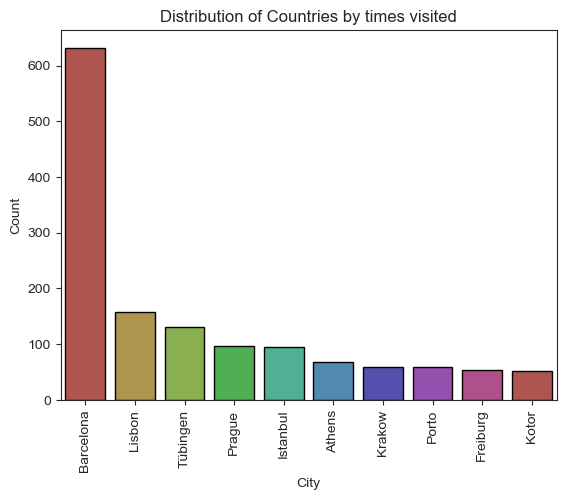

In [ ]:
# Q2: Draw the same bar chart, but now for the most visited cities instead of countries
city_counts = df["city"].value_counts().reset_index()
city_counts.columns = ["city", "count"]
city_counts = city_counts.head(10)

sns.set_style("ticks")
visited_countries = sns.barplot(x="city", y= "count", data=city_counts, hue = "city", palette=sns.hls_palette(9, l=.5, s=.5), edgecolor='k', legend = False)
visited_countries.set_title("Distribution of Cities by times visited")
visited_countries.set_ylabel('Count')
visited_countries.set_xlabel('City')
for item in visited_countries.get_xticklabels():
    item.set_rotation(90)

## Next: scatter plots as simple maps

<Axes: xlabel='lon', ylabel='lat'>

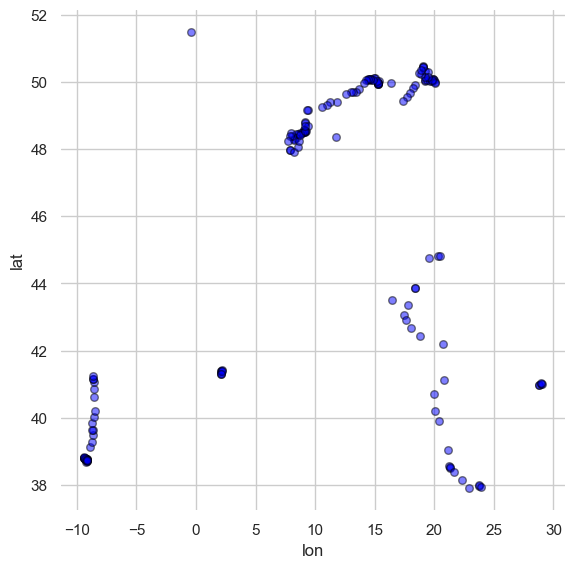

In [48]:
# Q3: Draw a scatter plot the longitude and latitude data, with matplotlib and seaborn defaults. 
# You can use the rs dataframe.
# Please style the chart to make it look nicer with good size and alpha settings. 
sns.set_theme(style="whitegrid")
f, ax = plt.subplots(figsize=(6.5, 6.5))
sns.despine(f, left=True, bottom=True)
sns.scatterplot(x="lon", y="lat", alpha=.5, edgecolor='black', s = 30,
                color="blue",
                sizes=(1, 8), linewidth=1,
                data=rs, ax=ax)

## Line charts, with annotation

In [75]:
# get the count of records by date
countdata = df.groupby(df.index.date).size()
countdata.columns = ["date", "count"]
countdata.head()

2014-05-14    36
2014-05-15    61
2014-05-16    57
2014-05-17    64
2014-05-18    50
dtype: int64

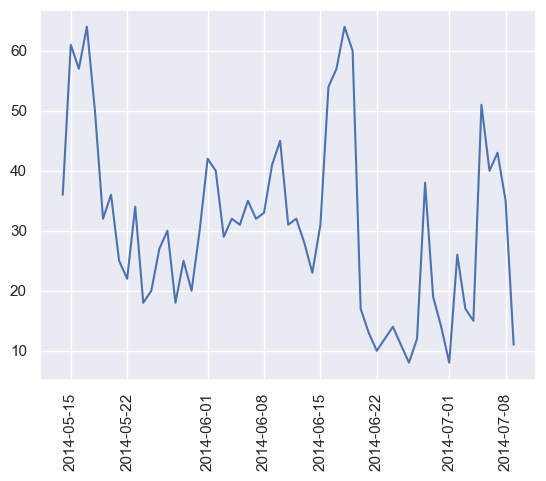

In [71]:
# Q4: Draw a  matplotlib and seaborn line chart from countdata. 
# Please style the chart to make it look nicer with good size and alpha settings. 
sns.set_theme(style="darkgrid")
countdata_chart = sns.lineplot(alpha=1,
             data=countdata)
for item in countdata_chart.get_xticklabels():
    item.set_rotation(90)

In [5]:
# Q5: Now you try: re-create the plot above with different line widths, colors, and point markers. 
# Play with moving the annotation labels around. Make the vertical tick marks 3 days apart instead of 5.
# experiment with a more advanced challenge like smoothing the line:
# - https://stackoverflow.com/questions/5283649/plot-smooth-line-with-pyplot
# - https://stackoverflow.com/questions/25825946/generating-smooth-line-graph-using-matplotlib

## Pie charts

In [4]:
cities = df['city'].value_counts()
print(cities.count())
cities.head()
city_values = cities.values
city_labels = cities.index

113


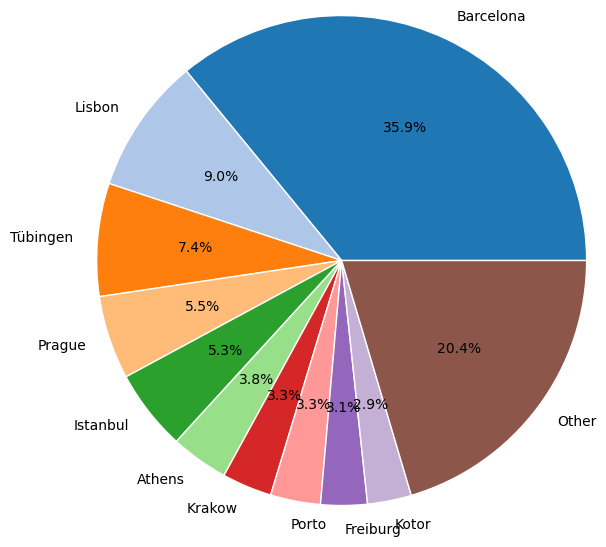

In [15]:
# Q6: draw a pie chart for cities.
# Please style the chart to make it look nicer. 
plt.style.use('_mpl-gallery-nogrid')


# make data
top = cities.head(10)
other = cities.iloc[10:].sum()

values = list(top.values) + [other]
labels = list(top.index) + ["Other"]

# plot
fig, ax = plt.subplots()
ax.pie(values, labels = labels, radius=10, center=(4, 4),autopct='%1.1f%%',
    colors=plt.cm.tab20.colors,
       wedgeprops={"linewidth": 1, "edgecolor": "white"})

ax.set(xlim=(0, 8), xticks=np.arange(1, 8),
       ylim=(0, 8), yticks=np.arange(1, 8))

plt.show()


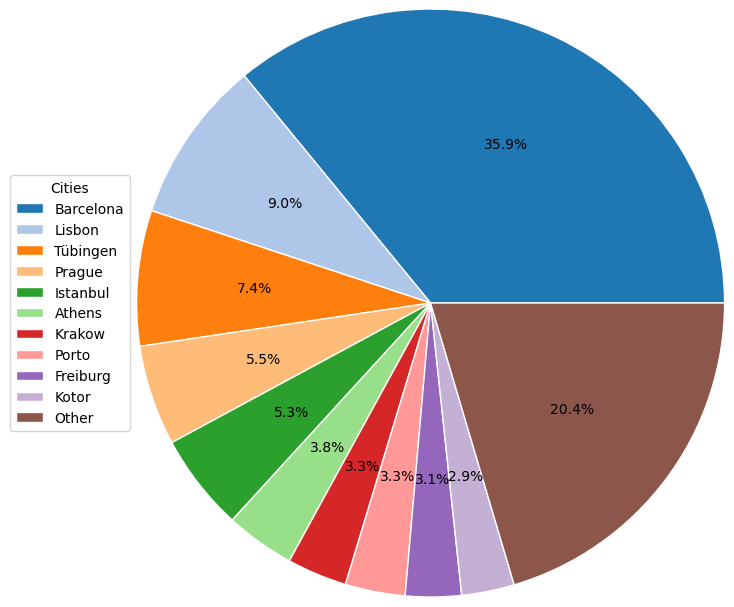

In [21]:
top = cities.head(10)
other = cities.iloc[10:].sum()

values = list(top.values) + [other]
labels = list(top.index) + ["Other"]

fig, ax = plt.subplots()

# Remove labels from the pie itself
wedges, _, _ = ax.pie(
    values,
    labels=None,                 # <-- no labels on the pie
    radius=12,
    center=(4, 4),
    autopct='%1.1f%%',
    colors=plt.cm.tab20.colors,
    wedgeprops={"linewidth": 1, "edgecolor": "white"}
)

# Add legend using the wedges + your labels
ax.legend(
    wedges,
    labels,
    title="Cities",
    loc="center right",
    bbox_to_anchor=(-1, 0.5)
)

ax.set(
    xlim=(0, 8), xticks=np.arange(1, 8),
    ylim=(0, 8), yticks=np.arange(1, 8)
)

plt.show()


## Extra task: Kepler.gl
Some examples: https://docs.kepler.gl/docs/keplergl-jupyter and https://jamesopacich.medium.com/display-a-kepler-gl-map-69d807dae082

In [ ]:
# Q7: can you visualize the GPS points by using Kepler.gl? 
